Author: B282025 <br>
MSc Bioinformatics Dissertation <br>
August 2026 <br>

Description: This script generates plots to compare the cell type composition 
between the Fibronectin Niche and Non-Fibronectin Niche regions within the
the tubular-interstitial tissue annotation.

Uses the same marker-parsing / cell-typing strategy as cell_type_analysis.ipynb.
Except, vascular cell classification is no longer needed since this analysis
was run on the tubular-interstitial compartment only. 

Cells are labeled as "Fibronectin Niche" / "Non-Fibronectin Niche" via the "Niche"
column produced by ExportNicheCellTypes.groovy<br>

A Fisher's exact test is used to test for significant enrichment.

Reference: This code was written using a combination of manual scripting and Claude Sonnet 5.

In [1]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from scipy.stats import fisher_exact

In [2]:
# ---------------------------------------------------------------------
# Shared plot styling (kept identical across all analysis notebooks)
# ---------------------------------------------------------------------


mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
})

In [3]:
# READ IN DATA
DATA_PATH = "../Akoya_Data/Aim1_Project/measurements/PPJ_07_2_Scan1_DB_fn_niche_detection_measurements.tsv"

df = pd.read_csv(DATA_PATH, sep='\t')
df.head()

,Image,Object ID,Object type,Classification,Tissue,Category,Description,Niche
0,PPJ_07_2_Scan1_DB_fn_niche.qptiff,0dadbdbe-f5d4-4af5-9a6f-27d462141c10,Cell,Non-Tubular Cell: CD45: CD68-: Non-Glom Cell: ...,NaN,NaN,NaN,NaN
1,PPJ_07_2_Scan1_DB_fn_niche.qptiff,081fb792-556c-4d96-b1a1-a37e4f26f46c,Cell,Tubular Cell: Vcam1: CD45-: CD68-: Non-Glom Ce...,NaN,NaN,NaN,NaN
2,PPJ_07_2_Scan1_DB_fn_niche.qptiff,ed79e3b1-ae80-4a64-b4e8-37fdaac224cb,Cell,Non-Tubular Cell: CD45-: CD68: Non-Glom Cell: ...,NaN,NaN,NaN,NaN
3,PPJ_07_2_Scan1_DB_fn_niche.qptiff,08c626ad-776e-4b7f-8a06-3c6594a2e3ba,Cell,Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell:...,NaN,NaN,NaN,NaN
4,PPJ_07_2_Scan1_DB_fn_niche.qptiff,6b922ebd-4ac9-4676-833a-2fc5c2f59ff6,Cell,Non-Tubular Cell: CD45-: CD68: Non-Glom Cell: ...,NaN,NaN,NaN,NaN


In [4]:
print(df.columns.tolist())

['Image', 'Object ID', 'Object type', 'Classification', 'Tissue', 'Category', 'Description', 'Niche']


In [5]:
# Sanity check
df['Classification'].value_counts()

Classification
Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin-: PDGFRb-: SMA-                               249291
Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin: PDGFRb-: SMA-                                 71650
Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin: PDGFRb: SMA-                              46719
Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin: PDGFRb-: SMA-                             45827
Non-Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin: PDGFRb: SMA                               45057
                                                                                                   ...  
Tubular Cell: p21: CD45-: CD68: Non-Glom Cell: Vimentin-: PDGFRb: SMA: Fibronectin                     1
Tubular Cell: p21: CD45: CD68: Glom Cell: Vimentin: PDGFRb: SMA-                                       1
Tubular Cell: p21: CD45-: CD68: Glom Cell: Vimentin: PDGFRb-: SMA-                                     1
Tubular Cell: p21: CD45-: CD68-: Glom Ce

In [6]:
# Sanity check
df['Niche'].value_counts(dropna=False)

Niche
Non-Fibronectin Niche    745459
Fibronectin Niche        160779
NaN                         742
Name: count, dtype: int64

## Cell type definitions

Same rules as cell_type_analysis.ipynb. Note that the vascular compartment has been removed, so no cells will be classified as vascular.

In [7]:
# Column names in the input TSV
CLASSIFICATION_COL = "Classification"
NICHE_COL = "Niche"

# Labels for cells that don't resolve to exactly one type
UNCLASSIFIED_LABEL = "Unclassified"
AMBIGUOUS_LABEL = "Ambiguous"


def parse_markers(classification: str) -> dict:
    """Parse a Classification string like
    'Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vimentin: PDGFRb-: SMA-'
    into a dict of {marker_name: True/False}.

    Handles three token conventions:
      - 'MarkerName'  -> True
      - 'MarkerName-' -> False
      - 'Non-Tubular Cell' / 'Non-Glom Cell' -> special-cased to
        {'Tubular Cell': False} / {'Glom Cell': False}
    """
    if pd.isna(classification):
        return {}
    markers = {}
    for tok in classification.split(":"):
        tok = tok.strip()
        if not tok:
            continue
        if tok == "Non-Tubular Cell":
            markers["Tubular Cell"] = False
        elif tok == "Non-Glom Cell":
            markers["Glom Cell"] = False
        elif tok.endswith("-"):
            markers[tok[:-1]] = False
        else:
            markers[tok] = True
    return markers


# Each rule takes the parsed marker dict and returns True/False.
# Vcam1/p21/Ki67 use .get(..., False) since they may be entirely absent (= negative).
# Markers that are always scored (Tubular Cell, Glom Cell, CD45, CD68, Vimentin,
# PDGFRb, SMA) use direct indexing.

CELL_TYPE_RULES = {
    "Healthy Tubule": lambda m: (
        m["Tubular Cell"]
        and not m.get("Vcam1", False)
        and not (m.get("p21", False) and not m.get("Ki67", False))
    ),
    "Injured Tubule":   lambda m: (
            m["Tubular Cell"] and m.get("Vcam1", False)
            and not (not m.get("Ki67", False) and m.get("p21", False))  # exclude the Senescent pattern
        ),
    "Senescent Tubule": lambda m: (
        m["Tubular Cell"] and not m.get("Ki67", False) and m.get("p21", False)
    ),
    "Macrophages": lambda m: m["CD45"] and m["CD68"],
    "Non-macrophage immune cells": lambda m: m["CD45"] and not m["CD68"],
    "Glomeruli cells": lambda m: m["Glom Cell"],
    "Fibroblasts": lambda m: (
        m["PDGFRb"] and not m["SMA"] and not m["Glom Cell"]
    ),
    "Myofibroblasts": lambda m: (
        m["PDGFRb"] and m["SMA"] and not m["Glom Cell"]
    ),
    "Other Mesenchymal Cell": lambda m: (
        m["Vimentin"]
        and not m["PDGFRb"]
        and not m["Tubular Cell"]
        and not m["Glom Cell"]
        and not m["CD45"]
    ),
}


def matching_types(markers: dict, rules: dict) -> list:
    """Return the list of ALL cell type names whose rule matches these markers
    (used to detect ambiguous / overlapping definitions)."""
    return [name for name, rule in rules.items() if rule(markers)]


def assign_cell_type_row(markers: dict, rules: dict):
    """Returns (assigned_type, all_marker_matches).

    0 marker matches -> Unclassified, >1 marker matches -> Ambiguous,
    exactly 1 -> that type.
    """
    matches = matching_types(markers, rules)
    if len(matches) == 0:
        return UNCLASSIFIED_LABEL, matches
    if len(matches) > 1:
        return AMBIGUOUS_LABEL, matches
    return matches[0], matches

## Summarize cell type composition by niche

summarize() assigns every cell to exactly one label (Healthy/Injured/Senescent Tubule,
Macrophages, Non-macrophage immune cells, Glomeruli cells, Fibroblasts, Myofibroblasts,
Other Mesenchymal Cell, Ambiguous, or Unclassified), then aggregates by Niche.
It returns two dataframes: the per-Niche/Cell-Type summary, and a table of every cell
that matched more than one type's rule (for sanity-checking the marker definitions).

In [8]:
ALL_LABELS = list(CELL_TYPE_RULES.keys()) + [AMBIGUOUS_LABEL, UNCLASSIFIED_LABEL]


def summarize(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Returns (summary, ambiguous_cells).

    summary: one row per (Niche, Cell Type) with Total Cells.
    ambiguous_cells: rows for every cell whose Classification matched more
        than one defined cell type's rule, showing every type it matched.
    """
    if CLASSIFICATION_COL not in df.columns:
        raise ValueError(f"column '{CLASSIFICATION_COL}' not found in input file.")
    if NICHE_COL not in df.columns:
        raise ValueError(
            f"column '{NICHE_COL}' not found in input file. "
            "Make sure the TSV was exported with Cell_Typing_v3.groovy."
        )

    df = df.copy()

    # Cells with no Niche would otherwise be silently dropped by groupby().
    n_missing_niche = df[NICHE_COL].isna().sum()
    if n_missing_niche > 0:
        print(f"NOTE: {n_missing_niche} cell(s) have no Niche; "
              f"labeling them 'Unknown' rather than dropping them.")
        df[NICHE_COL] = df[NICHE_COL].fillna("Unknown")

    df["_markers"] = df[CLASSIFICATION_COL].apply(parse_markers)

    assigned = df["_markers"].apply(lambda m: assign_cell_type_row(m, CELL_TYPE_RULES))
    df["Cell Type"] = assigned.apply(lambda x: x[0])
    df["_all_matches"] = assigned.apply(lambda x: x[1])

    # Ambiguity diagnostics: cells that matched more than one type's rule.
    ambiguous_mask = df["Cell Type"] == AMBIGUOUS_LABEL
    ambiguous_cells = df.loc[ambiguous_mask, [NICHE_COL, CLASSIFICATION_COL, "_all_matches"]].copy()
    ambiguous_cells = ambiguous_cells.rename(columns={
        NICHE_COL: "Niche",
        CLASSIFICATION_COL: "Classification",
        "_all_matches": "All Matching Types",
    })
    ambiguous_cells["All Matching Types"] = ambiguous_cells["All Matching Types"].apply(lambda types: ", ".join(types))

    if len(ambiguous_cells) > 0:
        print(f"WARNING: {len(ambiguous_cells)} cell(s) matched more than one cell type's rule. "
              f"These were labeled '{AMBIGUOUS_LABEL}' rather than force-assigned. "
              f"See the ambiguous_cells table for details.")

    rows = []
    for niche, niche_df in df.groupby(NICHE_COL):
        for cell_type in ALL_LABELS:
            type_df = niche_df[niche_df["Cell Type"] == cell_type]
            rows.append({
                "Niche": niche,
                "Cell Type": cell_type,
                "Total Cells": len(type_df),
            })

    result = pd.DataFrame(rows, columns=["Niche", "Cell Type", "Total Cells"])
    result = result.sort_values(["Cell Type", "Niche"]).reset_index(drop=True)
    return result, ambiguous_cells

In [9]:
# Run the summary
summary, ambiguous_cells = summarize(df)

NOTE: 742 cell(s) have no Niche; labeling them 'Unknown' rather than dropping them.


In [10]:
summary

,Niche,Cell Type,Total Cells
0,Fibronectin Niche,Ambiguous,46337
1,Non-Fibronectin Niche,Ambiguous,159150
2,Unknown,Ambiguous,66
3,Fibronectin Niche,Fibroblasts,10304
4,Non-Fibronectin Niche,Fibroblasts,63867
5,Unknown,Fibroblasts,80
6,Fibronectin Niche,Glomeruli cells,1044
7,Non-Fibronectin Niche,Glomeruli cells,5221
8,Unknown,Glomeruli cells,133
9,Fibronectin Niche,Healthy Tubule,53012


In [11]:
ambiguous_cells

,Niche,Classification,All Matching Types
7,Unknown,Non-Tubular Cell: CD45: CD68-: Non-Glom Cell: ...,"Non-macrophage immune cells, Myofibroblasts"
20,Unknown,Non-Tubular Cell: CD45: CD68-: Non-Glom Cell: ...,"Non-macrophage immune cells, Myofibroblasts"
39,Unknown,Non-Tubular Cell: CD45: CD68-: Non-Glom Cell: ...,"Non-macrophage immune cells, Fibroblasts"
41,Unknown,Non-Tubular Cell: CD45: CD68-: Non-Glom Cell: ...,"Non-macrophage immune cells, Myofibroblasts"
43,Unknown,Tubular Cell: CD45-: CD68-: Glom Cell: Vimenti...,"Healthy Tubule, Glomeruli cells"
...,...,...,...
906927,Non-Fibronectin Niche,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,"Healthy Tubule, Fibroblasts"
906930,Non-Fibronectin Niche,Non-Tubular Cell: CD45: CD68-: Non-Glom Cell: ...,"Non-macrophage immune cells, Myofibroblasts"
906935,Non-Fibronectin Niche,Tubular Cell: CD45: CD68-: Non-Glom Cell: Vime...,"Healthy Tubule, Non-macrophage immune cells"
906965,Non-Fibronectin Niche,Tubular Cell: CD45-: CD68-: Non-Glom Cell: Vim...,"Healthy Tubule, Fibroblasts"


In [12]:
ambiguous_cells["All Matching Types"].value_counts()

All Matching Types
Non-macrophage immune cells, Fibroblasts                          54495
Non-macrophage immune cells, Myofibroblasts                       45891
Healthy Tubule, Fibroblasts                                       21557
Macrophages, Fibroblasts                                          16501
Macrophages, Myofibroblasts                                       16227
Healthy Tubule, Myofibroblasts                                    13706
Healthy Tubule, Non-macrophage immune cells                        6737
Healthy Tubule, Non-macrophage immune cells, Fibroblasts           4281
Non-macrophage immune cells, Glomeruli cells                       3739
Injured Tubule, Fibroblasts                                        2979
Healthy Tubule, Non-macrophage immune cells, Myofibroblasts        2628
Healthy Tubule, Macrophages                                        2203
Healthy Tubule, Glomeruli cells                                    1881
Injured Tubule, Non-macrophage immune cells  

## Counts

Overall unresolved rate (Unclassified or Ambiguous), and cell counts per niche.

In [13]:
n_total = len(df)
n_unclassified = summary.loc[summary["Cell Type"] == UNCLASSIFIED_LABEL, "Total Cells"].sum()
n_ambiguous = summary.loc[summary["Cell Type"] == AMBIGUOUS_LABEL, "Total Cells"].sum()
n_unresolved = n_unclassified + n_ambiguous

print(f"Total cells: {n_total}")
print(f"Unclassified: {n_unclassified} ({n_unclassified / n_total:.1%})")
print(f"Ambiguous: {n_ambiguous} ({n_ambiguous / n_total:.1%})")
print(f"Unclassified + Ambiguous: {n_unresolved} ({n_unresolved / n_total:.1%})")
print()
print(summary.groupby("Niche")["Total Cells"].sum())

Total cells: 906980
Unclassified: 35390 (3.9%)
Ambiguous: 205553 (22.7%)
Unclassified + Ambiguous: 240943 (26.6%)

Niche
Fibronectin Niche        160779
Non-Fibronectin Niche    745459
Unknown                     742
Name: Total Cells, dtype: int64


In QuPath, I confirmed that the small group of 742 "Unknown"-niche cells is due to a small number of Fibronectin niche annotations extending slightly outside their parent Tissue annotation's boundary, so resolveHierarchy() detaches them (and their child cells) from the Tissue hierarchy, leaving those cells without Tissue/Category/Niche metadata.

## Plotting

In [14]:
NICHE_COLORS = {
    "Fibronectin Niche": "#0D97A7",
    "Non-Fibronectin Niche": "#89501E",
}

# Folder to save plot PNGs into (same folder as the input data file).
PLOT_OUTPUT_DIR = os.path.dirname(DATA_PATH)


def _get_niche_color(niche):
    color = NICHE_COLORS.get(niche)
    return color

### Cell type composition by niche

Proportion of each cell type within the Fibronectin Niche vs. the Non-Fibronectin Niche
(i.e. each niche's bars sum to 100%). The denominator for the proportion is the true
total per niche, including any Unclassified/Ambiguous cells. 

In [15]:
def plot_cell_type_proportions_by_niche(summary: pd.DataFrame, save_path: str = None) -> None:
    total_per_niche = summary.groupby("Niche")["Total Cells"].sum()

    # Exclude the Unknown niche (cells with no resolved Niche) from the plot
    # by default. Unclassified/Ambiguous cell types are now included as bars.
    plot_summary = summary[
        summary["Niche"] != "Unknown"
    ].copy()
    plot_summary["Proportion"] = plot_summary.apply(
        lambda row: 100.0 * row["Total Cells"] / total_per_niche[row["Niche"]]
        if total_per_niche[row["Niche"]] > 0 else np.nan,
        axis=1,
    )

    # Put resolved cell types first (in their original order of appearance),
    # then Unclassified/Ambiguous last, so they stand out at the end of the
    # x-axis rather than being interleaved with resolved types.
    cell_types = [
        ct for ct in dict.fromkeys(plot_summary["Cell Type"])
        if ct not in (UNCLASSIFIED_LABEL, AMBIGUOUS_LABEL)
    ]
    for label in (UNCLASSIFIED_LABEL, AMBIGUOUS_LABEL):
        if label in plot_summary["Cell Type"].values:
            cell_types.append(label)

    niches = list(dict.fromkeys(plot_summary["Niche"]))

    x = np.arange(len(cell_types))
    n_niche = max(len(niches), 1)
    width = 0.8 / n_niche

    fig, ax = plt.subplots(figsize=(max(6, len(cell_types) * 1.6), 6))
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", alpha=0.3)

    for i, niche in enumerate(niches):
        niche_summary = plot_summary[plot_summary["Niche"] == niche].set_index("Cell Type")
        values = [niche_summary["Proportion"].get(ct, np.nan) for ct in cell_types]
        totals = [niche_summary["Total Cells"].get(ct, 0) for ct in cell_types]
        offset = (i - (n_niche - 1) / 2) * width
        bars = ax.bar(x + offset, values, width, label=niche, color=_get_niche_color(niche),
                      edgecolor="black", linewidth=0.8)

        for bar, n in zip(bars, totals):
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f"n={n}", xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points",
                            ha="center", va="bottom", fontsize=8)

    ax.set_xlabel("Cell Type")
    ax.set_ylabel("Proportion of Cells in Niche (%)")
    ax.set_title("Cell Type Composition: Fibronectin Niche vs. Non-Fibronectin Niche")
    ax.set_xticks(x)
    ax.set_xticklabels(cell_types, rotation=45, ha="right")
    ax.legend(title="Niche")
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {save_path}")
    plt.show()


Saved plot to: ../Akoya_Data/Aim1_Project/measurements/cell_type_composition_by_niche.png


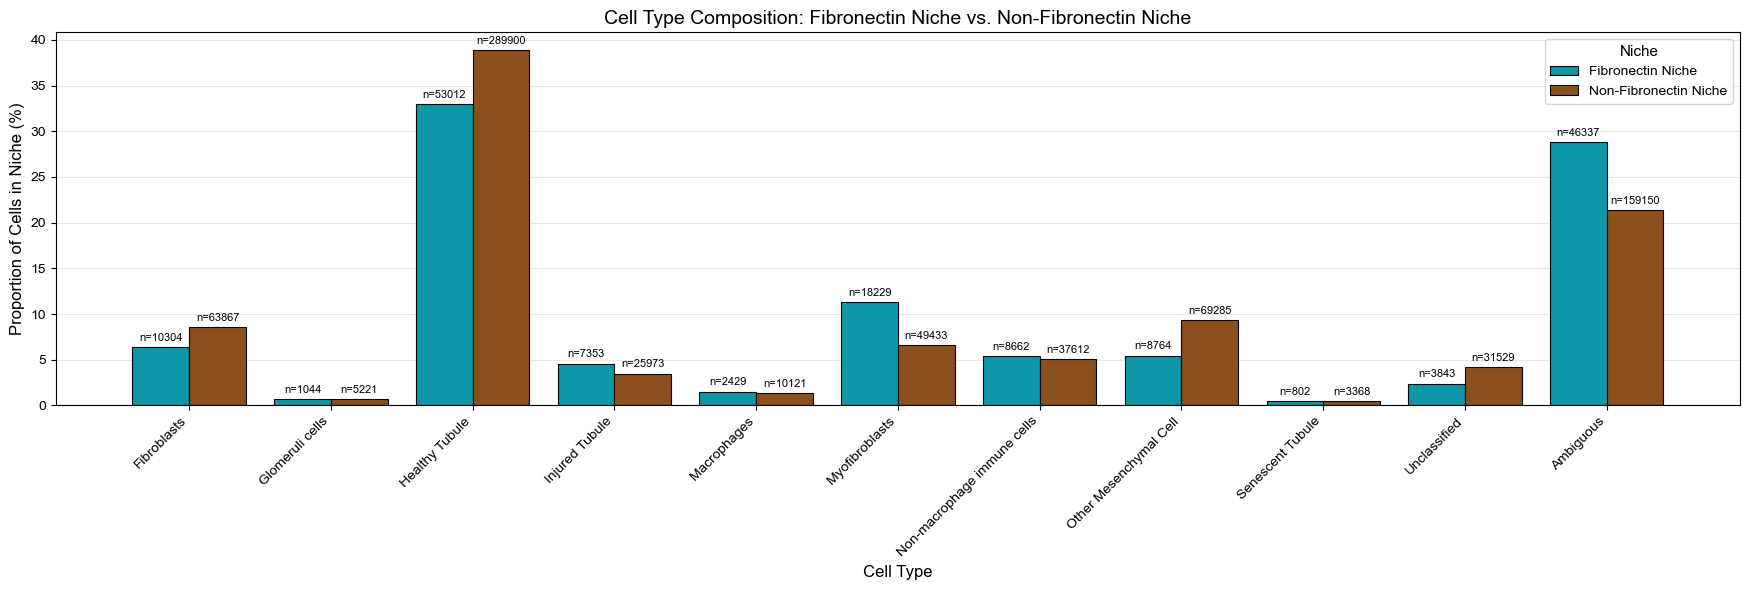

In [16]:
plot_cell_type_proportions_by_niche(
    summary,
    save_path=os.path.join(PLOT_OUTPUT_DIR, "cell_type_composition_by_niche.png"),
)

## Percentage-point enrichment of cell types in the Fibronectin Niche

For each cell type, we build a 2x2 contingency table (that cell type vs. all others, x
Fibronectin Niche vs. Non-Fibronectin Niche) and compute:

- effect size: percentage-point difference (% of Fibronectin Niche cells that are this type) -
  (% of Non-Fibronectin Niche cells that are this type). 
- p-value: Fisher's exact test on the 2x2 table. Fisher's exact calculates the
  exact probability of the observed table (or one more extreme), given the row/column
  totals, using the hypergeometric distribution.
- adjusted p-value: Benjamini-Hochberg FDR correction across all cell types tested.

Positive difference = more common in the Fibronectin Niche; negative = more common in
the Non-Fibronectin Niche. Bars are colored gray if not significant after FDR
correction (adj. p >= 0.05).

In [17]:
NICHE_A = "Fibronectin Niche"
NICHE_B = "Non-Fibronectin Niche"

# Cell types left out of the enrichment comparison entirely (in addition to
# Unclassified/Ambiguous, which are always excluded).
ENRICHMENT_EXCLUDE_TYPES = ["Glomeruli cells"]


def bh_correct(pvals):
    """Benjamini-Hochberg FDR correction."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order] * n / (np.arange(n) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]  # preserve order
    adj = np.empty(n)
    adj[order] = np.clip(ranked, 0, 1)
    return adj


def compute_enrichment(summary: pd.DataFrame, niche_a: str = NICHE_A, niche_b: str = NICHE_B) -> pd.DataFrame:
    """For each resolved cell type, compute the percentage-point difference in
    representation between niche_a and niche_b, a Fisher's exact test p-value,
    and its BH-adjusted p-value.
    """
    exclude_types = [UNCLASSIFIED_LABEL, AMBIGUOUS_LABEL] + ENRICHMENT_EXCLUDE_TYPES

    plot_summary = summary[
        ~summary["Cell Type"].isin(exclude_types)
        & summary["Niche"].isin([niche_a, niche_b])
    ]

    wide = plot_summary.pivot(index="Cell Type", columns="Niche", values="Total Cells").fillna(0)
    total_a = wide[niche_a].sum()
    total_b = wide[niche_b].sum()

    rows = []
    for cell_type, row in wide.iterrows():
        a = row[niche_a]
        c = row[niche_b]
        b = total_a - a
        d = total_b - c

        # Fisher's exact test on the raw 2x2 table:
        #
        #                    this cell type   all other cell types
        #   Fibronectin Niche       a                   b
        #   Non-Fibronectin Niche   c                   d
        #
        # Fisher's exact computes the exact probability of this table (or a
        # more extreme one), given the row/column totals, using the
        # hypergeometric distribution. 
        _, p_value = fisher_exact([[a, b], [c, d]])

        pct_a = 100.0 * a / total_a if total_a > 0 else np.nan
        pct_b = 100.0 * c / total_b if total_b > 0 else np.nan
        pct_diff = pct_a - pct_b

        rows.append({
            "Cell Type": cell_type,
            f"{niche_a} Count": int(a),
            f"{niche_a} Total": int(total_a),
            f"{niche_a} %": pct_a,
            f"{niche_b} Count": int(c),
            f"{niche_b} Total": int(total_b),
            f"{niche_b} %": pct_b,
            "Pct Point Diff": pct_diff,
            "p_value": p_value,
        })

    result = pd.DataFrame(rows)
    result["p_adj"] = bh_correct(result["p_value"].values)
    result["significant"] = result["p_adj"] < 0.05
    result = result.sort_values("Pct Point Diff", ascending=True).reset_index(drop=True)
    return result

In [18]:
enrichment = compute_enrichment(summary)
enrichment

,Cell Type,Fibronectin Niche Count,Fibronectin Niche Total,Fibronectin Niche %,Non-Fibronectin Niche Count,Non-Fibronectin Niche Total,Non-Fibronectin Niche %,Pct Point Diff,p_value,p_adj,significant
0,Other Mesenchymal Cell,8764,109555,7.999635,69285,549559,12.607382,-4.607747,0.000000e+00,0.000000e+00,True
1,Healthy Tubule,53012,109555,48.388481,289900,549559,52.751388,-4.362907,2.212331e-153,4.424661e-153,True
2,Fibroblasts,10304,109555,9.405322,63867,549559,11.621500,-2.216179,8.946375e-104,1.431420e-103,True
3,Senescent Tubule,802,109555,0.732052,3368,549559,0.612855,0.119197,7.928002e-06,7.928002e-06,True
4,Macrophages,2429,109555,2.217151,10121,549559,1.841658,0.375493,3.956881e-16,4.522149e-16,True
5,Non-macrophage immune cells,8662,109555,7.906531,37612,549559,6.844033,1.062498,3.132793e-35,4.177057e-35,True
6,Injured Tubule,7353,109555,6.711697,25973,549559,4.726153,1.985544,1.384723e-153,3.692595e-153,True
7,Myofibroblasts,18229,109555,16.639131,49433,549559,8.995031,7.644100,0.000000e+00,0.000000e+00,True


Saved plot to: ../Akoya_Data/Aim1_Project/measurements/cell_type_enrichment_fibronectin_niche_combined.png


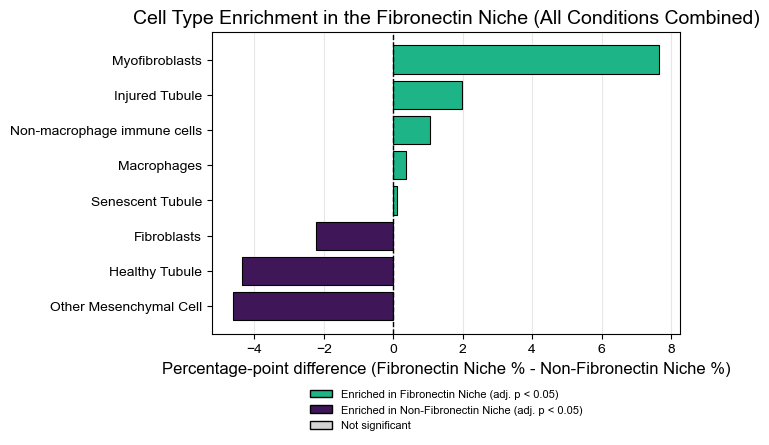

In [19]:
def plot_enrichment(enrichment: pd.DataFrame, save_path: str = None) -> None:
    """Combined (all conditions pooled) enrichment bar chart - same metric and
    styling as the by-condition plot below, so this can be compared directly
    against the per-condition panels."""
    df = enrichment.copy()
    y = np.arange(len(df))

    colors = []
    for _, row in df.iterrows():
        if not row["significant"]:
            colors.append("lightgray")
        elif row["Pct Point Diff"] > 0:
            colors.append("#1DB587")  # more common in Fibronectin Niche
        else:
            colors.append("#3F1758")  # more common in Non-Fibronectin Niche

    fig, ax = plt.subplots(figsize=(7, max(3, len(df) * 0.45) + 1.5))
    ax.set_axisbelow(True)
    ax.grid(axis="x", linestyle="-", alpha=0.3)
    ax.barh(y, df["Pct Point Diff"], color=colors, edgecolor="black", linewidth=0.8, zorder=2)

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(df["Cell Type"])
    ax.set_xlabel("Percentage-point difference (Fibronectin Niche % - Non-Fibronectin Niche %)")
    ax.set_title("Cell Type Enrichment in the Fibronectin Niche (All Conditions Combined)")

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1DB587', edgecolor='black', label='Enriched in Fibronectin Niche (adj. p < 0.05)'),
        Patch(facecolor='#3F1758', edgecolor='black', label='Enriched in Non-Fibronectin Niche (adj. p < 0.05)'),
        Patch(facecolor='lightgray', edgecolor='black', label='Not significant'),
    ]
    # Legend placed below the plot (rather than "best") so it doesn't overlap the bars.
    ax.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.15),
              ncol=1, fontsize=8, frameon=False)

    fig.tight_layout(rect=[0, 0.08, 1, 1])
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {save_path}")
    plt.show()


plot_enrichment(
    enrichment,
    save_path=os.path.join(PLOT_OUTPUT_DIR, "cell_type_enrichment_fibronectin_niche_combined.png"),
)

### Splitting the enrichment analysis by condition

The enrichment table above pools all tissue sections together. To see whether the
Fibronectin-Niche enrichment pattern holds in both Obstructed and Non-Obstructed
kidneys (rather than being driven by one group), we repeat the same Fisher's exact
enrichment analysis separately within each condition, using the Category column.

In [20]:
CATEGORY_COL = "Category"
CATEGORY_RENAME = {"ObK": "Obstructed", "Non-ObK": "Non-Obstructed"}
CONDITIONS = ["Non-Obstructed", "Obstructed"]


def summarize_by_condition(df: pd.DataFrame, category_col: str = CATEGORY_COL,
                            rename: dict = CATEGORY_RENAME) -> dict:
    """Split df by (renamed) condition and run summarize() on each subset.

    Returns {condition_name: summary_dataframe}.
    """
    df = df.copy()
    df["_Condition"] = df[category_col].map(lambda v: rename.get(v, v))

    unmapped = sorted(set(df[category_col].dropna().unique()) - set(rename.keys()))
    if unmapped:
        print(f"WARNING: found {category_col!r} value(s) not in CATEGORY_RENAME, "
              f"left as-is: {unmapped}")

    n_missing = df[category_col].isna().sum()
    if n_missing > 0:
        print(f"NOTE: {n_missing} cell(s) have no {category_col!r} value; "
              "excluded from the condition-split enrichment analysis.")

    summaries = {}
    for condition in CONDITIONS:
        cond_df = df[df["_Condition"] == condition]
        if cond_df.empty:
            print(f"WARNING: no cells found for condition {condition!r}.")
            continue
        print(f"--- {condition} ---")
        cond_summary, _ = summarize(cond_df)
        summaries[condition] = cond_summary
    return summaries


condition_summaries = summarize_by_condition(df)
condition_enrichment = {
    condition: compute_enrichment(cond_summary)
    for condition, cond_summary in condition_summaries.items()
}
condition_enrichment["Obstructed"]

NOTE: 742 cell(s) have no 'Category' value; excluded from the condition-split enrichment analysis.
--- Non-Obstructed ---
--- Obstructed ---


,Cell Type,Fibronectin Niche Count,Fibronectin Niche Total,Fibronectin Niche %,Non-Fibronectin Niche Count,Non-Fibronectin Niche Total,Non-Fibronectin Niche %,Pct Point Diff,p_value,p_adj,significant
0,Healthy Tubule,20788,64778,32.091142,150448,367190,40.972793,-8.881651,0.000000e+00,0.000000e+00,True
1,Fibroblasts,6119,64778,9.446108,53496,367190,14.569024,-5.122916,3.085204e-289,8.227210e-289,True
2,Other Mesenchymal Cell,5603,64778,8.649542,47625,367190,12.970124,-4.320583,3.860978e-226,6.177565e-226,True
3,Senescent Tubule,61,64778,0.094168,1027,367190,0.279692,-0.185524,3.469843e-22,3.469843e-22,True
4,Macrophages,2286,64778,3.528976,9778,367190,2.662927,0.866049,7.067099e-33,8.076684e-33,True
5,Non-macrophage immune cells,8087,64778,12.484177,35302,367190,9.614096,2.870080,1.906153e-105,2.541537e-105,True
6,Injured Tubule,6968,64778,10.756738,24793,367190,6.752090,4.004648,3.088090e-257,6.176181e-257,True
7,Myofibroblasts,14866,64778,22.949149,44721,367190,12.179253,10.769896,0.000000e+00,0.000000e+00,True


In [21]:
condition_enrichment["Non-Obstructed"]

,Cell Type,Fibronectin Niche Count,Fibronectin Niche Total,Fibronectin Niche %,Non-Fibronectin Niche Count,Non-Fibronectin Niche Total,Non-Fibronectin Niche %,Pct Point Diff,p_value,p_adj,significant
0,Other Mesenchymal Cell,3161,44777,7.059428,21660,182369,11.877019,-4.817591,1.983325e-206,7.933301e-206,True
1,Healthy Tubule,32224,44777,71.965518,139452,182369,76.466943,-4.501425,8.181941e-86,1.636388e-85,True
2,Non-macrophage immune cells,575,44777,1.284141,2310,182369,1.266663,0.017479,7.595378e-01,7.595378e-01,False
3,Macrophages,143,44777,0.319360,343,182369,0.188080,0.131280,3.186415e-07,4.248553e-07,True
4,Injured Tubule,385,44777,0.859816,1180,182369,0.647040,0.212777,1.972078e-06,2.253804e-06,True
5,Senescent Tubule,741,44777,1.654867,2341,182369,1.283661,0.371206,2.953575e-09,4.725720e-09,True
6,Fibroblasts,4185,44777,9.346316,10371,182369,5.686822,3.659494,1.491341e-161,3.976908e-161,True
7,Myofibroblasts,3363,44777,7.510552,4712,182369,2.583772,4.926780,0.000000e+00,0.000000e+00,True


Saved plot to: ../Akoya_Data/Aim1_Project/measurements/cell_type_enrichment_fibronectin_niche_by_condition.png


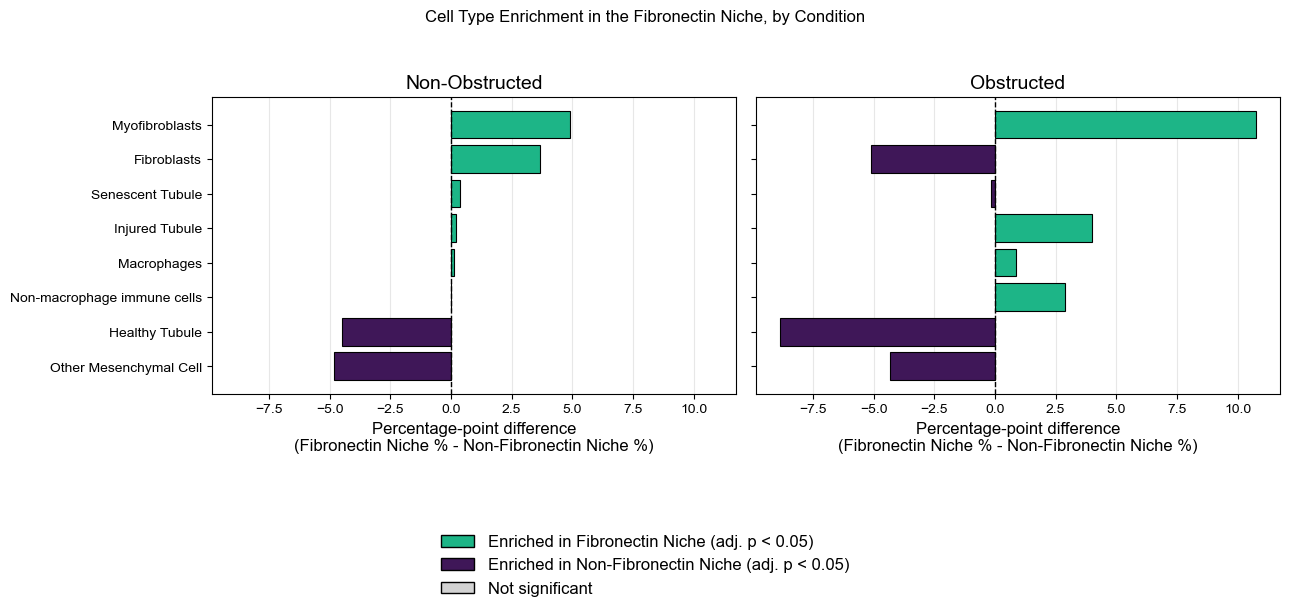

In [22]:
def plot_enrichment_by_condition(condition_enrichment: dict, save_path: str = None) -> None:
    """Two side-by-side bar charts (Obstructed | Non-Obstructed), each showing
    the same Fisher's-exact percentage-point enrichment as the single-panel
    plot above, so the Fibronectin-Niche pattern can be compared across
    conditions. Both panels share the same x-axis range and the same cell
    type order (taken from the first condition) so rows line up directly.
    """
    conditions = [c for c in CONDITIONS if c in condition_enrichment]
    if len(conditions) != 2:
        raise ValueError(f"Expected exactly 2 conditions to plot, got: {conditions}")

    # Use one condition's cell-type order (sorted by effect size) for both
    # panels, so the same row means the same cell type in each plot.
    order = condition_enrichment[conditions[0]].set_index("Cell Type").index.tolist()

    # Shared x-axis range across both panels, so the magnitude of enrichment
    # is directly comparable between conditions.
    all_diffs = pd.concat([condition_enrichment[c]["Pct Point Diff"] for c in conditions])
    xmin, xmax = all_diffs.min(), all_diffs.max()
    pad = 0.05 * (xmax - xmin) if xmax > xmin else 1.0
    xlim = (xmin - pad, xmax + pad)

    fig, axes = plt.subplots(1, 2, figsize=(13, max(3, len(order) * 0.45) + 1.5), sharey=True)

    for ax, condition in zip(axes, conditions):
        cond_df = condition_enrichment[condition].set_index("Cell Type").reindex(order)
        y = np.arange(len(order))

        colors = []
        for _, row in cond_df.iterrows():
            if pd.isna(row["Pct Point Diff"]):
                colors.append("white")
            elif not row["significant"]:
                colors.append("lightgray")
            elif row["Pct Point Diff"] > 0:
                colors.append("#1DB587")  # more common in Fibronectin Niche
            else:
                colors.append("#3F1758")  # more common in Non-Fibronectin Niche

        ax.set_axisbelow(True)
        ax.grid(axis="x", linestyle="-", alpha=0.3)
        ax.barh(y, cond_df["Pct Point Diff"], color=colors, edgecolor="black",
                linewidth=0.8, zorder=2)
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_yticks(y)
        ax.set_yticklabels(order)
        ax.set_xlim(xlim)
        ax.set_xlabel("Percentage-point difference\n(Fibronectin Niche % - Non-Fibronectin Niche %)")
        ax.set_title(condition)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1DB587', edgecolor='black', label='Enriched in Fibronectin Niche (adj. p < 0.05)'),
        Patch(facecolor='#3F1758', edgecolor='black', label='Enriched in Non-Fibronectin Niche (adj. p < 0.05)'),
        Patch(facecolor='lightgray', edgecolor='black', label='Not significant'),
    ]
    fig.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, 0),
               ncol=1, fontsize=12, frameon=False)

    fig.suptitle("Cell Type Enrichment in the Fibronectin Niche, by Condition", y=1)
    fig.tight_layout(rect=[0, 0.1, 1, 0.96])
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {save_path}")
    plt.show()


plot_enrichment_by_condition(
    condition_enrichment,
    save_path=os.path.join(PLOT_OUTPUT_DIR, "cell_type_enrichment_fibronectin_niche_by_condition.png"),
)

### Save cell type file (optional) <br>
This file can be imported back into QuPath to visualize the cell types.

In [23]:
# Add the assigned Cell Type as a new column, then save the annotated data as a new TSV.
df["_markers"] = df[CLASSIFICATION_COL].apply(parse_markers)
df["Cell Type"] = df["_markers"].apply(lambda m: assign_cell_type_row(m, CELL_TYPE_RULES)[0])
df = df.drop(columns=["_markers"])  # drop the intermediate helper column before saving


In [24]:
output_path = DATA_PATH.replace(".tsv", "_with_celltype.tsv")
df.to_csv(output_path, sep="\t", index=False)
print(f"Saved {len(df)} rows with Cell Type column to: {output_path}")

Saved 906980 rows with Cell Type column to: ../Akoya_Data/Aim1_Project/measurements/PPJ_07_2_Scan1_DB_fn_niche_detection_measurements_with_celltype.tsv
